In [27]:
# --- Repro (safe, minimal) ---
import os, random, numpy as np, torch
SEED = 12345
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.set_num_threads(4)


In [28]:
# --- Path plumbing (point to src) + autoreload ---
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import ROOT as ROOT_CFG, PROCESSED_DIR, CLEANED
print("CWD:", NB)
print("SRC:", SRC)
print("ROOT:", ROOT_CFG)
print("PROC:", PROCESSED_DIR)
print("CLEANED:", CLEANED)


# --- 0) Imports & paths ---
from pathlib import Path
import numpy as np

from simulator.env import HedgingEnv
from simulator.rewards import pnl_only
from rl_agent.policy_nn import PolicyNetwork, PolicyConfig
from rl_agent.trainer import train_reinforce, TrainConfig, evaluate_env
from simulator.baselines import volatility_targeting, momentum_policy, delta_hedge_policy


from rl_agent.train_ac_gae import train as train_gae
from rl_agent.experiment import (
    build_envs,
    deterministic_rewards,
    augment_panel_with_baseline_features,
    build_aligned_env_bundle,
    make_tuned_baselines,
)
from rl_agent.trainer import evaluate_env

from pathlib import Path
import numpy as np
import json

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CWD: /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked/notebooks
SRC: /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked/src
ROOT: /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked
PROC: /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked/data/processed
CLEANED: /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked/data/processed/cleaned


In [29]:
# --- 1) Load panel exported from 02_simulator ---
panel = pd.read_csv(CLEANED / "hedging_panel_spx.csv", parse_dates=["date"])
panel = panel.sort_values("date").reset_index(drop=True)

print("Panel window:", panel["date"].min(), "→", panel["date"].max())
print("Columns:", list(panel.columns)[:12], "...")

Panel window: 2005-01-21 00:00:00 → 2023-08-29 00:00:00
Columns: ['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d', 'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d', 'hvol_182d'] ...


In [ ]:
# Assume `panel` already loaded and has 'date', 'ret_fwd', and your feature columns
panel = panel.sort_values("date").set_index("date")

state_cols = [
    c for c in [
        "iv_atm_30d_spx","iv_ts_slope_spx","iv_skew_30d_spx",
        "vix","rate_10y","rv_21d","hvol_30d","hvol_91d","delta_atm_30d_spx",
        "ret_1d","close_spy_z60", "rv_60d" 
    ] if c in panel.columns
]
print("STATE_COLS:", state_cols)
display(panel.head(3))


STATE_COLS: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d', 'delta_atm_30d_spx', 'rv_60d']


,close_spy,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,...,delta_atm_30d_spx,iv_atm_60d_spx,iv_ts_slope_spx,iv_put25_30d_spx,iv_call25_30d_spx,iv_skew_30d_spx,iv_put25_60d_spx,iv_call25_60d_spx,iv_skew_60d_spx,ret_fwd
date,,,,,,,,,,,,,,,,,,,,,
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [35]:
# changing to 8 features as mentionedin paper
panel = panel.sort_values("date").set_index("date")

state_cols = [
    c for c in [
        "iv_atm_30d_spx","iv_ts_slope_spx","iv_skew_30d_spx",
        "vix","rate_10y","rv_21d","hvol_30d","hvol_91d"
    ] if c in panel.columns
]
print("STATE_COLS:", state_cols)
display(panel.head(3))


STATE_COLS: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']


,close_spy,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,...,delta_atm_30d_spx,iv_atm_60d_spx,iv_ts_slope_spx,iv_put25_30d_spx,iv_call25_30d_spx,iv_skew_30d_spx,iv_put25_60d_spx,iv_call25_60d_spx,iv_skew_60d_spx,ret_fwd
date,,,,,,,,,,,,,,,,,,,,,
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0



> Note: The baseline REINFORCE smoke test was moved to `02_simulator.ipynb`. This notebook now starts with the GAE training loop.


# Gae Training for all 

### Actor–Critic (GAE) script run

We replace REINFORCE with a lower-variance Actor–Critic (policy + value head, GAE),
entropy/LR schedules, grad clipping, and checkpoint on best VALID Sharpe.


In [36]:
panel = panel.copy()
panel = panel.reset_index()  # Reset index to have 'date' as a column
panel.head(3)

,date,close_spy,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,...,delta_atm_30d_spx,iv_atm_60d_spx,iv_ts_slope_spx,iv_put25_30d_spx,iv_call25_30d_spx,iv_skew_30d_spx,iv_put25_60d_spx,iv_call25_60d_spx,iv_skew_60d_spx,ret_fwd
0,2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [15]:
# --- Parameter sweep: cadence vs slippage (realistic trading assumptions) ---
from itertools import product
import json
import time
import pandas as pd

# Define grid of realistic trading knobs
SWEEP_GRID = {
    "rebalance_every": [15, 20, 25],
    "slippage_bps": [8.0, 10.0 , 15.0, 20.0],
    "pos_limit": [2.0],
}

# Base hyperparameters (aligned with recent run)
BASE_TRAIN_KW = dict(
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=45,
    txn_cost_bps=10.0,
    hidden=256,
    lr=1e-4,
    steps=8000,
    entropy_start=0.01,
    entropy_floor=0.001,
    device="cpu",
    seed=42,
    weight_decay=1e-4,
    early_stop_patience=600,
    max_rollout_steps=400,
)

FORCE_RETRAIN = False  # set True to rerun even if results.json already exists
RESULTS_ROOT = ROOT / "models" / "sweep_run"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

records = []
grid = list(product(
    SWEEP_GRID["rebalance_every"],
    SWEEP_GRID["slippage_bps"],
    SWEEP_GRID["pos_limit"],
))
print(f"Total combinations: {len(grid)}")
start_all = time.time()
for idx, (rebalance_every, slippage_bps, pos_limit) in enumerate(grid, 1):
    tag = f"cad{rebalance_every}_slip{slippage_bps}_pos{pos_limit}".replace('.', 'p')
    outdir = RESULTS_ROOT / tag
    outdir.mkdir(parents=True, exist_ok=True)
    ckpt_path = outdir / "best.pt"
    config_path = outdir / "config.json"
    results_path = outdir / "results.json"

    print(f"\n[{idx}/{len(grid)}] {tag}")
    if results_path.exists() and not FORCE_RETRAIN:
        metrics = json.loads(results_path.read_text())
        tr_metrics = metrics["train"]
        va_metrics = metrics["valid"]
        te_metrics = metrics["test"]
    else:
        result = train_gae(
            panel=panel,
            state_cols=state_cols,
            pos_limit=pos_limit,
            rebalance_every=rebalance_every,
            slippage_bps=slippage_bps,
            save_ckpt=str(ckpt_path),
            save_config=str(config_path),
            save_outdir=str(outdir),
            track_history=False,
            return_history=False,
            **BASE_TRAIN_KW,
        )
        if isinstance(result, tuple) and len(result) == 3:
            policy, metrics_tuple, _ = result
        else:
            policy, metrics_tuple = result
        tr_metrics, va_metrics, te_metrics = metrics_tuple
        metrics = {"train": tr_metrics, "valid": va_metrics, "test": te_metrics}
        results_path.write_text(json.dumps(metrics, indent=2))

    records.append({
        "tag": tag,
        "rebalance_every": rebalance_every,
        "slippage_bps": slippage_bps,
        "pos_limit": pos_limit,
        "train_sharpe": tr_metrics["sharpe"],
        "valid_sharpe": va_metrics["sharpe"],
        "test_sharpe": te_metrics["sharpe"],
        "valid_mean": va_metrics["mean"],
        "test_mean": te_metrics["mean"],
        "valid_std": va_metrics["std"],
        "test_std": te_metrics["std"],
    })

elapsed = time.time() - start_all
print(f"\nSweep completed in {elapsed/60:.1f} minutes")

sweep_df = pd.DataFrame(records).sort_values(by=['test_sharpe', 'valid_sharpe'], ascending=False).reset_index(drop=True)
display(sweep_df)
print("Best configuration candidate:")
print(sweep_df.iloc[0])



Total combinations: 12

[1/12] cad15_slip8p0_pos2p0
Env(train) ready. input_dim=450 (window=45, n_features=10)
[00050] Train Sharpe -0.558 | Valid Sharpe -0.594 | Test Sharpe  -0.598 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe -0.179 | Valid Sharpe -0.406 | Test Sharpe  -0.262 | LR 1.00e-04 | Ent 0.010
[00150] Train Sharpe -0.320 | Valid Sharpe -0.398 | Test Sharpe  -0.419 | LR 9.99e-05 | Ent 0.010
[00200] Train Sharpe -0.279 | Valid Sharpe -0.398 | Test Sharpe  -0.419 | LR 9.98e-05 | Ent 0.009
[00250] Train Sharpe -0.095 | Valid Sharpe -0.295 | Test Sharpe  -0.209 | LR 9.98e-05 | Ent 0.009
[00300] Train Sharpe 0.190 | Valid Sharpe 0.279 | Test Sharpe  0.047 | LR 9.97e-05 | Ent 0.009
[00350] Train Sharpe 0.251 | Valid Sharpe 0.522 | Test Sharpe  0.099 | LR 9.95e-05 | Ent 0.009
[00400] Train Sharpe 0.309 | Valid Sharpe 0.556 | Test Sharpe  0.315 | LR 9.94e-05 | Ent 0.009
[00450] Train Sharpe 0.325 | Valid Sharpe 0.604 | Test Sharpe  0.314 | LR 9.92e-05 | Ent 0.009
[00500] Train Sharp

,tag,rebalance_every,slippage_bps,pos_limit,train_sharpe,valid_sharpe,test_sharpe,valid_mean,test_mean,valid_std,test_std
0,cad25_slip8p0_pos2p0,25,8.0,2.0,0.423917,0.772185,0.560115,2.851449,2.148146,58.619868,60.881650
1,cad25_slip15p0_pos2p0,25,15.0,2.0,0.568750,0.855276,0.541650,3.063573,2.040954,56.862034,59.815663
2,cad25_slip10p0_pos2p0,25,10.0,2.0,0.371150,0.776383,0.530243,2.863391,2.032709,58.547071,60.855650
3,cad25_slip20p0_pos2p0,25,20.0,2.0,0.521361,0.914487,0.418057,3.299850,1.594056,57.281846,60.529652
4,cad20_slip20p0_pos2p0,20,20.0,2.0,0.120720,0.693868,0.194678,2.234437,0.645254,51.120100,52.615513
5,cad20_slip15p0_pos2p0,20,15.0,2.0,0.205797,0.768009,0.107739,2.530826,0.382144,52.311375,56.306206
6,cad20_slip8p0_pos2p0,20,8.0,2.0,0.336974,0.892943,0.046347,3.149031,0.173301,55.982679,59.357713
7,cad15_slip20p0_pos2p0,15,20.0,2.0,0.188624,0.543753,0.030535,1.891956,0.110200,55.234437,57.291091
8,cad20_slip10p0_pos2p0,20,10.0,2.0,0.312863,0.869156,0.027951,3.055148,0.104339,55.800059,59.258087
9,cad15_slip8p0_pos2p0,15,8.0,2.0,0.270680,0.735750,0.020298,2.532962,0.075511,54.651075,59.053553


Best configuration candidate:
tag                cad25_slip8p0_pos2p0
rebalance_every                      25
slippage_bps                        8.0
pos_limit                           2.0
train_sharpe                   0.423917
valid_sharpe                   0.772185
test_sharpe                    0.560115
valid_mean                     2.851449
test_mean                      2.148146
valid_std                     58.619868
test_std                       60.88165
Name: 0, dtype: object


In [16]:
sweep_df.to_pickle("sweep_df_original.pkl")

In [18]:
sweep_df

,tag,rebalance_every,slippage_bps,pos_limit,train_sharpe,valid_sharpe,test_sharpe,valid_mean,test_mean,valid_std,test_std
0,cad25_slip8p0_pos2p0,25,8.0,2.0,0.423917,0.772185,0.560115,2.851449,2.148146,58.619868,60.881650
1,cad25_slip15p0_pos2p0,25,15.0,2.0,0.568750,0.855276,0.541650,3.063573,2.040954,56.862034,59.815663
2,cad25_slip10p0_pos2p0,25,10.0,2.0,0.371150,0.776383,0.530243,2.863391,2.032709,58.547071,60.855650
3,cad25_slip20p0_pos2p0,25,20.0,2.0,0.521361,0.914487,0.418057,3.299850,1.594056,57.281846,60.529652
4,cad20_slip20p0_pos2p0,20,20.0,2.0,0.120720,0.693868,0.194678,2.234437,0.645254,51.120100,52.615513
5,cad20_slip15p0_pos2p0,20,15.0,2.0,0.205797,0.768009,0.107739,2.530826,0.382144,52.311375,56.306206
6,cad20_slip8p0_pos2p0,20,8.0,2.0,0.336974,0.892943,0.046347,3.149031,0.173301,55.982679,59.357713
7,cad15_slip20p0_pos2p0,15,20.0,2.0,0.188624,0.543753,0.030535,1.891956,0.110200,55.234437,57.291091
8,cad20_slip10p0_pos2p0,20,10.0,2.0,0.312863,0.869156,0.027951,3.055148,0.104339,55.800059,59.258087
9,cad15_slip8p0_pos2p0,15,8.0,2.0,0.270680,0.735750,0.020298,2.532962,0.075511,54.651075,59.053553


In [11]:
# new param sweep 1 according to exact params used in the paper:
# used list 4's hyperparams
# Define grid of realistic trading knobs
SWEEP_GRID = {
    "rebalance_every": [15, 20, 25],
    "slippage_bps": [8.0, 10.0 , 15.0, 20.0],
    "pos_limit": [2.0],
}

# modified hyperparams
BASE_TRAIN_KW = dict(
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=30,            # mentioend in paper
    txn_cost_bps=10.0,     
    hidden=256,            
    lr=5e-4,               # mentioned in paper list 4
    steps=2500,            # mentioned in paper list 4
    entropy_start=0.01,    
    entropy_floor=0.01,    # since mentioned fixed entropy
    device="cpu",        
    seed=42,               
    weight_decay=1e-4,     
    early_stop_patience=600, 
    max_rollout_steps=400,
)

FORCE_RETRAIN = False  # set True to rerun even if results.json already exists
RESULTS_ROOT = ROOT / "models" / "sweep_run"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

records = []
grid = list(product(
    SWEEP_GRID["rebalance_every"],
    SWEEP_GRID["slippage_bps"],
    SWEEP_GRID["pos_limit"],
))
print(f"Total combinations: {len(grid)}")
start_all = time.time()
for idx, (rebalance_every, slippage_bps, pos_limit) in enumerate(grid, 1):
    tag = f"cad{rebalance_every}_slip{slippage_bps}_pos{pos_limit}".replace('.', 'p')
    outdir = RESULTS_ROOT / tag
    outdir.mkdir(parents=True, exist_ok=True)
    ckpt_path = outdir / "best.pt"
    config_path = outdir / "config.json"
    results_path = outdir / "results.json"

    print(f"\n[{idx}/{len(grid)}] {tag}")
    if results_path.exists() and not FORCE_RETRAIN:
        metrics = json.loads(results_path.read_text())
        tr_metrics = metrics["train"]
        va_metrics = metrics["valid"]
        te_metrics = metrics["test"]
    else:
        result = train_gae(
            panel=panel,
            state_cols=state_cols,
            pos_limit=pos_limit,
            rebalance_every=rebalance_every,
            slippage_bps=slippage_bps,
            save_ckpt=str(ckpt_path),
            save_config=str(config_path),
            save_outdir=str(outdir),
            track_history=False,
            return_history=False,
            **BASE_TRAIN_KW,
        )
        if isinstance(result, tuple) and len(result) == 3:
            policy, metrics_tuple, _ = result
        else:
            policy, metrics_tuple = result
        tr_metrics, va_metrics, te_metrics = metrics_tuple
        metrics = {"train": tr_metrics, "valid": va_metrics, "test": te_metrics}
        results_path.write_text(json.dumps(metrics, indent=2))

    records.append({
        "tag": tag,
        "rebalance_every": rebalance_every,
        "slippage_bps": slippage_bps,
        "pos_limit": pos_limit,
        "train_sharpe": tr_metrics["sharpe"],
        "valid_sharpe": va_metrics["sharpe"],
        "test_sharpe": te_metrics["sharpe"],
        "valid_mean": va_metrics["mean"],
        "test_mean": te_metrics["mean"],
        "valid_std": va_metrics["std"],
        "test_std": te_metrics["std"],
    })

elapsed = time.time() - start_all
print(f"\nSweep completed in {elapsed/60:.1f} minutes")

sweep_df = pd.DataFrame(records).sort_values(by=['test_sharpe', 'valid_sharpe'], ascending=False).reset_index(drop=True)
display(sweep_df)
print("Best configuration candidate:")
print(sweep_df.iloc[0])



Total combinations: 12

[1/12] cad15_slip8p0_pos2p0
Env(train) ready. input_dim=300 (window=30, n_features=10)
[00050] Train Sharpe 0.318 | Valid Sharpe 0.482 | Test Sharpe  -0.003 | LR 5.00e-04 | Ent 0.010
[00100] Train Sharpe 0.231 | Valid Sharpe 0.420 | Test Sharpe  0.002 | LR 4.98e-04 | Ent 0.010
[00150] Train Sharpe 0.355 | Valid Sharpe 0.495 | Test Sharpe  0.022 | LR 4.96e-04 | Ent 0.010
[00200] Train Sharpe 0.373 | Valid Sharpe 0.502 | Test Sharpe  0.000 | LR 4.92e-04 | Ent 0.010
[00250] Train Sharpe 0.351 | Valid Sharpe 0.461 | Test Sharpe  -0.014 | LR 4.88e-04 | Ent 0.010
[00300] Train Sharpe 0.361 | Valid Sharpe 0.498 | Test Sharpe  -0.045 | LR 4.82e-04 | Ent 0.010
[00350] Train Sharpe 0.333 | Valid Sharpe 0.339 | Test Sharpe  0.002 | LR 4.76e-04 | Ent 0.010
[00400] Train Sharpe 0.379 | Valid Sharpe 0.392 | Test Sharpe  -0.018 | LR 4.69e-04 | Ent 0.010
[00450] Train Sharpe 0.401 | Valid Sharpe 0.452 | Test Sharpe  -0.059 | LR 4.61e-04 | Ent 0.010
[00500] Train Sharpe 0.359 | 

,tag,rebalance_every,slippage_bps,pos_limit,train_sharpe,valid_sharpe,test_sharpe,valid_mean,test_mean,valid_std,test_std
0,cad20_slip20p0_pos2p0,20,20.0,2.0,0.434089,0.541618,0.067126,1.293763,0.201712,37.919420,47.702844
1,cad15_slip10p0_pos2p0,15,10.0,2.0,0.357998,0.486571,0.044243,1.652331,0.158531,53.907780,56.881631
2,cad20_slip8p0_pos2p0,20,8.0,2.0,0.458246,0.602859,-0.022491,2.121817,-0.084373,55.871787,59.552844
3,cad25_slip10p0_pos2p0,25,10.0,2.0,0.610415,0.673834,-0.028317,2.126481,-0.094959,50.096693,53.234019
4,cad25_slip15p0_pos2p0,25,15.0,2.0,0.608938,0.650515,-0.031922,2.054633,-0.107766,50.139177,53.590256
5,cad15_slip20p0_pos2p0,15,20.0,2.0,0.234881,0.388506,-0.032387,1.317305,-0.117010,53.825645,57.352020
6,cad25_slip20p0_pos2p0,25,20.0,2.0,0.625841,0.600994,-0.032871,1.909534,-0.111443,50.437924,53.820145
7,cad15_slip8p0_pos2p0,15,8.0,2.0,0.508791,0.535925,-0.033956,1.722417,-0.115029,51.019326,53.776623
8,cad20_slip10p0_pos2p0,20,10.0,2.0,0.446802,0.584454,-0.036129,2.074841,-0.135692,56.355323,59.621158
9,cad25_slip8p0_pos2p0,25,8.0,2.0,0.587906,0.674767,-0.046559,2.209812,-0.161126,51.987846,54.937146


Best configuration candidate:
tag                cad20_slip20p0_pos2p0
rebalance_every                       20
slippage_bps                        20.0
pos_limit                            2.0
train_sharpe                    0.434089
valid_sharpe                    0.541618
test_sharpe                     0.067126
valid_mean                      1.293763
test_mean                       0.201712
valid_std                       37.91942
test_std                       47.702844
Name: 0, dtype: object


In [12]:
# New parameter sweep 2: only changed window size to be 30
# Define grid of realistic trading knobs
SWEEP_GRID = {
    "rebalance_every": [15, 20, 25],
    "slippage_bps": [8.0, 10.0 , 15.0, 20.0],
    "pos_limit": [2.0],
}

# Base hyperparameters (aligned with recent run)
BASE_TRAIN_KW = dict(
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=30,
    txn_cost_bps=10.0,
    hidden=256,
    lr=1e-4,
    steps=8000,
    entropy_start=0.01,
    entropy_floor=0.001,
    device="cpu",
    seed=42,
    weight_decay=1e-4,
    early_stop_patience=600,
    max_rollout_steps=400,
)

FORCE_RETRAIN = False  # set True to rerun even if results.json already exists
RESULTS_ROOT = ROOT / "models" / "sweep_run"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

records = []
grid = list(product(
    SWEEP_GRID["rebalance_every"],
    SWEEP_GRID["slippage_bps"],
    SWEEP_GRID["pos_limit"],
))
print(f"Total combinations: {len(grid)}")
start_all = time.time()
for idx, (rebalance_every, slippage_bps, pos_limit) in enumerate(grid, 1):
    tag = f"cad{rebalance_every}_slip{slippage_bps}_pos{pos_limit}".replace('.', 'p')
    outdir = RESULTS_ROOT / tag
    outdir.mkdir(parents=True, exist_ok=True)
    ckpt_path = outdir / "best.pt"
    config_path = outdir / "config.json"
    results_path = outdir / "results.json"

    print(f"\n[{idx}/{len(grid)}] {tag}")
    if results_path.exists() and not FORCE_RETRAIN:
        metrics = json.loads(results_path.read_text())
        tr_metrics = metrics["train"]
        va_metrics = metrics["valid"]
        te_metrics = metrics["test"]
    else:
        result = train_gae(
            panel=panel,
            state_cols=state_cols,
            pos_limit=pos_limit,
            rebalance_every=rebalance_every,
            slippage_bps=slippage_bps,
            save_ckpt=str(ckpt_path),
            save_config=str(config_path),
            save_outdir=str(outdir),
            track_history=False,
            return_history=False,
            **BASE_TRAIN_KW,
        )
        if isinstance(result, tuple) and len(result) == 3:
            policy, metrics_tuple, _ = result
        else:
            policy, metrics_tuple = result
        tr_metrics, va_metrics, te_metrics = metrics_tuple
        metrics = {"train": tr_metrics, "valid": va_metrics, "test": te_metrics}
        results_path.write_text(json.dumps(metrics, indent=2))

    records.append({
        "tag": tag,
        "rebalance_every": rebalance_every,
        "slippage_bps": slippage_bps,
        "pos_limit": pos_limit,
        "train_sharpe": tr_metrics["sharpe"],
        "valid_sharpe": va_metrics["sharpe"],
        "test_sharpe": te_metrics["sharpe"],
        "valid_mean": va_metrics["mean"],
        "test_mean": te_metrics["mean"],
        "valid_std": va_metrics["std"],
        "test_std": te_metrics["std"],
    })

elapsed = time.time() - start_all
print(f"\nSweep completed in {elapsed/60:.1f} minutes")

sweep_df = pd.DataFrame(records).sort_values(by=['test_sharpe', 'valid_sharpe'], ascending=False).reset_index(drop=True)
display(sweep_df)
print("Best configuration candidate:")
print(sweep_df.iloc[0])



Total combinations: 12

[1/12] cad15_slip8p0_pos2p0
Env(train) ready. input_dim=300 (window=30, n_features=10)
[00050] Train Sharpe 0.520 | Valid Sharpe 0.080 | Test Sharpe  0.257 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe 0.413 | Valid Sharpe -0.052 | Test Sharpe  0.241 | LR 1.00e-04 | Ent 0.010
[00150] Train Sharpe 0.662 | Valid Sharpe -0.078 | Test Sharpe  0.318 | LR 9.99e-05 | Ent 0.010
[00200] Train Sharpe 0.548 | Valid Sharpe -0.240 | Test Sharpe  0.118 | LR 9.98e-05 | Ent 0.009
[00250] Train Sharpe 0.497 | Valid Sharpe 0.263 | Test Sharpe  0.443 | LR 9.98e-05 | Ent 0.009
[00300] Train Sharpe 0.452 | Valid Sharpe 0.449 | Test Sharpe  0.378 | LR 9.97e-05 | Ent 0.009
[00350] Train Sharpe 0.403 | Valid Sharpe 0.540 | Test Sharpe  0.173 | LR 9.95e-05 | Ent 0.009
[00400] Train Sharpe 0.399 | Valid Sharpe 0.501 | Test Sharpe  0.260 | LR 9.94e-05 | Ent 0.009
[00450] Train Sharpe 0.396 | Valid Sharpe 0.543 | Test Sharpe  0.177 | LR 9.92e-05 | Ent 0.009
[00500] Train Sharpe 0.392 | Va

,tag,rebalance_every,slippage_bps,pos_limit,train_sharpe,valid_sharpe,test_sharpe,valid_mean,test_mean,valid_std,test_std
0,cad15_slip20p0_pos2p0,15,20.0,2.0,0.313122,0.583590,0.049691,1.943185,0.180166,52.857493,57.557136
1,cad15_slip8p0_pos2p0,15,8.0,2.0,0.392995,0.575876,0.043665,1.930130,0.159120,53.205722,57.847992
2,cad20_slip20p0_pos2p0,20,20.0,2.0,0.377944,0.438264,0.030502,1.477562,0.103097,53.519268,53.655221
3,cad15_slip10p0_pos2p0,15,10.0,2.0,0.371214,0.580246,0.028715,1.934329,0.105182,52.919851,58.147166
4,cad20_slip8p0_pos2p0,20,8.0,2.0,0.488543,0.549493,0.015952,1.862598,0.055670,53.809329,55.399730
5,cad15_slip15p0_pos2p0,15,15.0,2.0,0.332935,0.575095,0.011026,1.902212,0.040414,52.507266,58.185147
6,cad20_slip10p0_pos2p0,20,10.0,2.0,0.467394,0.534522,0.007561,1.816175,0.026443,53.937663,55.515859
7,cad20_slip15p0_pos2p0,20,15.0,2.0,0.429295,0.491225,0.001551,1.663949,0.005396,53.772446,55.221130
8,cad25_slip8p0_pos2p0,25,8.0,2.0,0.652203,0.682141,-0.002084,2.219000,-0.007281,51.639669,55.470866
9,cad25_slip10p0_pos2p0,25,10.0,2.0,0.611700,0.668132,-0.011792,2.203780,-0.041619,52.360798,56.028181


Best configuration candidate:
tag                cad15_slip20p0_pos2p0
rebalance_every                       15
slippage_bps                        20.0
pos_limit                            2.0
train_sharpe                    0.313122
valid_sharpe                     0.58359
test_sharpe                     0.049691
valid_mean                      1.943185
test_mean                       0.180166
valid_std                      52.857493
test_std                       57.557136
Name: 0, dtype: object


In [13]:
sweep_df.to_pickle("sweep_df_new2.pkl")

In [34]:
# New parameter sweep 3: only changed to constant entropy
# Define grid of realistic trading knobs
SWEEP_GRID = {
    "rebalance_every": [15, 20, 25],
    "slippage_bps": [8.0, 10.0 , 15.0, 20.0],
    "pos_limit": [2.0],
}

# Base hyperparameters (aligned with recent run)
BASE_TRAIN_KW = dict(
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=45,
    txn_cost_bps=10.0,
    hidden=256,
    lr=1e-4,
    steps=8000,
    entropy_start=0.01,
    entropy_floor=0.01,
    device="cpu",
    seed=42,
    weight_decay=1e-4,
    early_stop_patience=600,
    max_rollout_steps=400,
)

FORCE_RETRAIN = False  # set True to rerun even if results.json already exists
RESULTS_ROOT = ROOT / "models" / "sweep_run_constant_e"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

records = []
grid = list(product(
    SWEEP_GRID["rebalance_every"],
    SWEEP_GRID["slippage_bps"],
    SWEEP_GRID["pos_limit"],
))
print(f"Total combinations: {len(grid)}")
start_all = time.time()
for idx, (rebalance_every, slippage_bps, pos_limit) in enumerate(grid, 1):
    tag = f"cad{rebalance_every}_slip{slippage_bps}_pos{pos_limit}".replace('.', 'p')
    outdir = RESULTS_ROOT / tag
    outdir.mkdir(parents=True, exist_ok=True)
    ckpt_path = outdir / "best.pt"
    config_path = outdir / "config.json"
    results_path = outdir / "results.json"

    print(f"\n[{idx}/{len(grid)}] {tag}")
    if results_path.exists() and not FORCE_RETRAIN:
        metrics = json.loads(results_path.read_text())
        tr_metrics = metrics["train"]
        va_metrics = metrics["valid"]
        te_metrics = metrics["test"]
    else:
        result = train_gae(
            panel=panel,
            state_cols=state_cols,
            pos_limit=pos_limit,
            rebalance_every=rebalance_every,
            slippage_bps=slippage_bps,
            save_ckpt=str(ckpt_path),
            save_config=str(config_path),
            save_outdir=str(outdir),
            track_history=False,
            return_history=False,
            **BASE_TRAIN_KW,
        )
        if isinstance(result, tuple) and len(result) == 3:
            policy, metrics_tuple, _ = result
        else:
            policy, metrics_tuple = result
        tr_metrics, va_metrics, te_metrics = metrics_tuple
        metrics = {"train": tr_metrics, "valid": va_metrics, "test": te_metrics}
        results_path.write_text(json.dumps(metrics, indent=2))

    records.append({
        "tag": tag,
        "rebalance_every": rebalance_every,
        "slippage_bps": slippage_bps,
        "pos_limit": pos_limit,
        "train_sharpe": tr_metrics["sharpe"],
        "valid_sharpe": va_metrics["sharpe"],
        "test_sharpe": te_metrics["sharpe"],
        "valid_mean": va_metrics["mean"],
        "test_mean": te_metrics["mean"],
        "valid_std": va_metrics["std"],
        "test_std": te_metrics["std"],
    })

elapsed = time.time() - start_all
print(f"\nSweep completed in {elapsed/60:.1f} minutes")

sweep_df = pd.DataFrame(records).sort_values(by=['test_sharpe', 'valid_sharpe'], ascending=False).reset_index(drop=True)
display(sweep_df)
print("Best configuration candidate:")
print(sweep_df.iloc[0])



Total combinations: 12

[1/12] cad15_slip8p0_pos2p0
Env(train) ready. input_dim=360 (window=45, n_features=8)
[00050] Train Sharpe 0.150 | Valid Sharpe -0.117 | Test Sharpe  0.074 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe -0.002 | Valid Sharpe -0.188 | Test Sharpe  -0.106 | LR 1.00e-04 | Ent 0.010
[00150] Train Sharpe -0.075 | Valid Sharpe -0.226 | Test Sharpe  -0.130 | LR 9.99e-05 | Ent 0.010
[00200] Train Sharpe -0.075 | Valid Sharpe -0.247 | Test Sharpe  -0.098 | LR 9.98e-05 | Ent 0.010
[00250] Train Sharpe 0.042 | Valid Sharpe -0.224 | Test Sharpe  0.200 | LR 9.98e-05 | Ent 0.010
[00300] Train Sharpe 0.121 | Valid Sharpe 0.186 | Test Sharpe  0.439 | LR 9.97e-05 | Ent 0.010
[00350] Train Sharpe 0.146 | Valid Sharpe 0.181 | Test Sharpe  0.428 | LR 9.95e-05 | Ent 0.010
[00400] Train Sharpe 0.163 | Valid Sharpe 0.260 | Test Sharpe  0.427 | LR 9.94e-05 | Ent 0.010
[00450] Train Sharpe 0.158 | Valid Sharpe 0.338 | Test Sharpe  0.413 | LR 9.92e-05 | Ent 0.010
[00500] Train Sharpe 0.1

,tag,rebalance_every,slippage_bps,pos_limit,train_sharpe,valid_sharpe,test_sharpe,valid_mean,test_mean,valid_std,test_std
0,cad20_slip8p0_pos2p0,20,8.0,2.0,0.239281,0.751524,0.242769,2.693068,0.888328,56.885881,58.087094
1,cad20_slip10p0_pos2p0,20,10.0,2.0,0.223722,0.725915,0.233561,2.593385,0.859236,56.712887,58.399966
2,cad15_slip8p0_pos2p0,15,8.0,2.0,0.098270,0.617506,0.195683,1.957640,0.690635,50.325927,56.026884
3,cad15_slip20p0_pos2p0,15,20.0,2.0,-0.008593,0.083228,0.184147,0.127140,0.372347,24.250040,32.098412
4,cad15_slip15p0_pos2p0,15,15.0,2.0,0.078797,0.171890,0.180975,0.183088,0.250895,16.908706,22.007648
5,cad20_slip15p0_pos2p0,20,15.0,2.0,0.168973,0.676115,0.171748,2.377266,0.601403,55.815847,55.587108
6,cad25_slip20p0_pos2p0,25,20.0,2.0,-0.011388,0.302630,0.163224,0.655127,0.426233,34.364781,41.453705
7,cad15_slip10p0_pos2p0,15,10.0,2.0,0.112196,0.632085,0.157676,2.027899,0.570166,50.929672,57.403243
8,cad20_slip20p0_pos2p0,20,20.0,2.0,0.050229,0.567777,0.152604,1.919498,0.550661,53.667324,57.282068
9,cad25_slip8p0_pos2p0,25,8.0,2.0,0.088255,0.885284,0.056189,3.200360,0.221559,57.387375,62.594741


Best configuration candidate:
tag                cad20_slip8p0_pos2p0
rebalance_every                      20
slippage_bps                        8.0
pos_limit                           2.0
train_sharpe                   0.239281
valid_sharpe                   0.751524
test_sharpe                    0.242769
valid_mean                     2.693068
test_mean                      0.888328
valid_std                     56.885881
test_std                      58.087094
Name: 0, dtype: object


In [37]:
# New parameter sweep 4: changed to constant entropy, with only features mentioned in paper
# Define grid of realistic trading knobs
SWEEP_GRID = {
    "rebalance_every": [15, 20, 25],
    "slippage_bps": [8.0, 10.0 , 15.0, 20.0],
    "pos_limit": [2.0],
}

# Base hyperparameters (aligned with recent run)
BASE_TRAIN_KW = dict(
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=45,
    txn_cost_bps=10.0,
    hidden=256,
    lr=1e-4,
    steps=8000,
    entropy_start=0.01,
    entropy_floor=0.01,
    device="cpu",
    seed=42,
    weight_decay=1e-4,
    early_stop_patience=600,
    max_rollout_steps=400,
)

FORCE_RETRAIN = False  # set True to rerun even if results.json already exists
RESULTS_ROOT = ROOT / "models" / "sweep_run_constant_e"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

records = []
grid = list(product(
    SWEEP_GRID["rebalance_every"],
    SWEEP_GRID["slippage_bps"],
    SWEEP_GRID["pos_limit"],
))
print(f"Total combinations: {len(grid)}")
start_all = time.time()
for idx, (rebalance_every, slippage_bps, pos_limit) in enumerate(grid, 1):
    tag = f"cad{rebalance_every}_slip{slippage_bps}_pos{pos_limit}".replace('.', 'p')
    outdir = RESULTS_ROOT / tag
    outdir.mkdir(parents=True, exist_ok=True)
    ckpt_path = outdir / "best.pt"
    config_path = outdir / "config.json"
    results_path = outdir / "results.json"

    print(f"\n[{idx}/{len(grid)}] {tag}")
    if results_path.exists() and not FORCE_RETRAIN:
        metrics = json.loads(results_path.read_text())
        tr_metrics = metrics["train"]
        va_metrics = metrics["valid"]
        te_metrics = metrics["test"]
    else:
        result = train_gae(
            panel=panel,
            state_cols=state_cols,
            pos_limit=pos_limit,
            rebalance_every=rebalance_every,
            slippage_bps=slippage_bps,
            save_ckpt=str(ckpt_path),
            save_config=str(config_path),
            save_outdir=str(outdir),
            track_history=False,
            return_history=False,
            **BASE_TRAIN_KW,
        )
        if isinstance(result, tuple) and len(result) == 3:
            policy, metrics_tuple, _ = result
        else:
            policy, metrics_tuple = result
        tr_metrics, va_metrics, te_metrics = metrics_tuple
        metrics = {"train": tr_metrics, "valid": va_metrics, "test": te_metrics}
        results_path.write_text(json.dumps(metrics, indent=2))

    records.append({
        "tag": tag,
        "rebalance_every": rebalance_every,
        "slippage_bps": slippage_bps,
        "pos_limit": pos_limit,
        "train_sharpe": tr_metrics["sharpe"],
        "valid_sharpe": va_metrics["sharpe"],
        "test_sharpe": te_metrics["sharpe"],
        "valid_mean": va_metrics["mean"],
        "test_mean": te_metrics["mean"],
        "valid_std": va_metrics["std"],
        "test_std": te_metrics["std"],
    })

elapsed = time.time() - start_all
print(f"\nSweep completed in {elapsed/60:.1f} minutes")

sweep_df = pd.DataFrame(records).sort_values(by=['test_sharpe', 'valid_sharpe'], ascending=False).reset_index(drop=True)
display(sweep_df)
print("Best configuration candidate:")
print(sweep_df.iloc[0])



Total combinations: 12

[1/12] cad15_slip8p0_pos2p0
Env(train) ready. input_dim=360 (window=45, n_features=8)
[00050] Train Sharpe 0.222 | Valid Sharpe 0.052 | Test Sharpe  0.230 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe 0.066 | Valid Sharpe -0.182 | Test Sharpe  -0.076 | LR 1.00e-04 | Ent 0.010
[00150] Train Sharpe -0.008 | Valid Sharpe -0.185 | Test Sharpe  -0.083 | LR 9.99e-05 | Ent 0.010
[00200] Train Sharpe -0.013 | Valid Sharpe -0.190 | Test Sharpe  -0.076 | LR 9.98e-05 | Ent 0.010
[00250] Train Sharpe -0.007 | Valid Sharpe -0.184 | Test Sharpe  -0.049 | LR 9.98e-05 | Ent 0.010
[00300] Train Sharpe 0.201 | Valid Sharpe 0.055 | Test Sharpe  0.378 | LR 9.97e-05 | Ent 0.010
[00350] Train Sharpe 0.185 | Valid Sharpe 0.035 | Test Sharpe  0.185 | LR 9.95e-05 | Ent 0.010
[00400] Train Sharpe 0.207 | Valid Sharpe 0.022 | Test Sharpe  0.145 | LR 9.94e-05 | Ent 0.010
[00450] Train Sharpe 0.212 | Valid Sharpe -0.008 | Test Sharpe  0.125 | LR 9.92e-05 | Ent 0.010
[00500] Train Sharpe 0.

,tag,rebalance_every,slippage_bps,pos_limit,train_sharpe,valid_sharpe,test_sharpe,valid_mean,test_mean,valid_std,test_std
0,cad25_slip10p0_pos2p0,25,10.0,2.0,-0.057155,0.800290,0.470576,2.615717,1.572734,51.885223,53.054968
1,cad25_slip8p0_pos2p0,25,8.0,2.0,-0.067777,0.791856,0.407128,2.609728,1.389796,52.317793,54.190151
2,cad15_slip8p0_pos2p0,15,8.0,2.0,0.200895,0.054972,0.378316,0.034263,0.304103,9.894293,12.760480
3,cad25_slip15p0_pos2p0,25,15.0,2.0,0.105678,0.176333,0.266243,0.232292,0.390323,20.912303,23.272694
4,cad20_slip15p0_pos2p0,20,15.0,2.0,0.145583,0.615833,0.258860,2.049601,0.940919,52.833137,57.701677
5,cad20_slip8p0_pos2p0,20,8.0,2.0,0.378111,0.651270,0.245064,2.362133,0.882415,57.576276,57.160081
6,cad20_slip10p0_pos2p0,20,10.0,2.0,0.335559,0.625778,0.231450,2.266920,0.859341,57.506422,58.939757
7,cad15_slip10p0_pos2p0,15,10.0,2.0,0.165813,0.027553,0.175040,0.050964,0.412375,29.363287,37.398658
8,cad15_slip15p0_pos2p0,15,15.0,2.0,0.387092,0.579537,0.151660,0.232098,0.098497,6.357549,10.309864
9,cad25_slip20p0_pos2p0,25,20.0,2.0,0.223349,-0.115498,0.145506,-0.021028,0.038308,2.890201,4.179301


Best configuration candidate:
tag                cad25_slip10p0_pos2p0
rebalance_every                       25
slippage_bps                        10.0
pos_limit                            2.0
train_sharpe                   -0.057155
valid_sharpe                     0.80029
test_sharpe                     0.470576
valid_mean                      2.615717
test_mean                       1.572734
valid_std                      51.885223
test_std                       53.054968
Name: 0, dtype: object


In [19]:
# --- Train final GAE run using best sweep configuration ---
best_row = sweep_df.iloc[0]
print("Using best sweep params:", best_row.to_dict())

RUN_DIR = ROOT / "models" / f"gae_{best_row['tag']}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CFG = dict(
    panel=panel,
    state_cols=state_cols,
    train_end=BASE_TRAIN_KW["train_end"],
    valid_end=BASE_TRAIN_KW["valid_end"],
    window=BASE_TRAIN_KW["window"],
    txn_cost_bps=BASE_TRAIN_KW["txn_cost_bps"],
    pos_limit=float(best_row["pos_limit"]),
    rebalance_every=int(best_row["rebalance_every"]),
    slippage_bps=float(best_row["slippage_bps"]),
    hidden=BASE_TRAIN_KW["hidden"],
    lr=BASE_TRAIN_KW["lr"],
    steps=BASE_TRAIN_KW["steps"],
    entropy_start=BASE_TRAIN_KW["entropy_start"],
    entropy_floor=BASE_TRAIN_KW["entropy_floor"],
    device=BASE_TRAIN_KW["device"],
    seed=BASE_TRAIN_KW["seed"],
    weight_decay=BASE_TRAIN_KW["weight_decay"],
    early_stop_patience=BASE_TRAIN_KW["early_stop_patience"],
    max_rollout_steps=BASE_TRAIN_KW["max_rollout_steps"],
    save_ckpt=str(RUN_DIR / "best.pt"),
    save_config=str(RUN_DIR / "config.json"),
    save_outdir=str(RUN_DIR),
    track_history=True,
    return_history=True,
)

policy_ac, (tr_ac, va_ac, te_ac), history_ac = train_gae(**FINAL_CFG)
print("GAE (TRAIN):", tr_ac)
print("GAE (VALID):", va_ac)
print("GAE (TEST) :", te_ac)

FINAL_PARAMS = {
    "train_end": FINAL_CFG["train_end"],
    "valid_end": FINAL_CFG["valid_end"],
    "window": FINAL_CFG["window"],
    "txn_cost_bps": FINAL_CFG["txn_cost_bps"],
    "pos_limit": FINAL_CFG["pos_limit"],
    "rebalance_every": FINAL_CFG["rebalance_every"],
    "slippage_bps": FINAL_CFG["slippage_bps"],
}



Using best sweep params: {'tag': 'cad25_slip8p0_pos2p0', 'rebalance_every': 25, 'slippage_bps': 8.0, 'pos_limit': 2.0, 'train_sharpe': 0.423917090858278, 'valid_sharpe': 0.7721845632950739, 'test_sharpe': 0.5601154669865464, 'valid_mean': 2.8514494716834435, 'test_mean': 2.148145590723558, 'valid_std': 58.619867866418666, 'test_std': 60.8816504595934}
Env(train) ready. input_dim=450 (window=45, n_features=10)
[00050] Train Sharpe -0.449 | Valid Sharpe -0.465 | Test Sharpe  -0.479 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe -0.120 | Valid Sharpe -0.695 | Test Sharpe  -0.259 | LR 1.00e-04 | Ent 0.010
[00150] Train Sharpe -0.399 | Valid Sharpe -0.709 | Test Sharpe  -0.513 | LR 9.99e-05 | Ent 0.010
[00200] Train Sharpe -0.404 | Valid Sharpe -0.696 | Test Sharpe  -0.655 | LR 9.98e-05 | Ent 0.009
[00250] Train Sharpe -0.142 | Valid Sharpe -0.515 | Test Sharpe  -0.264 | LR 9.98e-05 | Ent 0.009
[00300] Train Sharpe 0.222 | Valid Sharpe 0.151 | Test Sharpe  0.407 | LR 9.97e-05 | Ent 0.009
[0

In [33]:
# new rl train by directly fixing window = 30 and 8, 2, 25

RUN_DIR = ROOT / "models" / f"gae_manual"
RUN_DIR.mkdir(parents=True, exist_ok=True)

# changed features according to Section 4
state_cols = [
    "iv_atm_30d_spx", "iv_ts_slope_spx", "iv_skew_30d_spx", 
    "vix", "rate_10y", "rv_21d", "hvol_30d", "hvol_91d"
]

# mannually define hyperparams
FINAL_CFG = dict(
    panel=panel,
    state_cols=state_cols,
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=30,            
    txn_cost_bps=10.0,     
    pos_limit=2.0,         
    rebalance_every=25,    
    slippage_bps=8.0,     
    hidden=256,
    lr=1e-4,               
    steps=8000,            
    entropy_start=0.01,
    entropy_floor=0.001,   
    device="cpu",          
    seed=42,               
    weight_decay=1e-4,
    early_stop_patience=600,
    max_rollout_steps=400,
    save_ckpt=str(RUN_DIR / "best_paper_v2.pt"),
    save_config=str(RUN_DIR / "config_paper_v2.json"),
)

policy_ac, (tr_ac, va_ac, te_ac) = train_gae(**FINAL_CFG)
print("GAE (TRAIN):", tr_ac)
print("GAE (VALID):", va_ac)
print("GAE (TEST) :", te_ac)

FINAL_PARAMS = {
    "train_end": FINAL_CFG["train_end"],
    "valid_end": FINAL_CFG["valid_end"],
    "window": FINAL_CFG["window"],
    "txn_cost_bps": FINAL_CFG["txn_cost_bps"],
    "pos_limit": FINAL_CFG["pos_limit"],
    "rebalance_every": FINAL_CFG["rebalance_every"],
    "slippage_bps": FINAL_CFG["slippage_bps"],
}

Env(train) ready. input_dim=240 (window=30, n_features=8)
[00050] Train Sharpe -0.002 | Valid Sharpe 0.234 | Test Sharpe  0.070 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe -0.083 | Valid Sharpe -0.038 | Test Sharpe  -0.073 | LR 1.00e-04 | Ent 0.010
[00150] Train Sharpe -0.085 | Valid Sharpe -0.050 | Test Sharpe  -0.065 | LR 9.99e-05 | Ent 0.010
[00200] Train Sharpe -0.060 | Valid Sharpe 0.102 | Test Sharpe  -0.067 | LR 9.98e-05 | Ent 0.009
[00250] Train Sharpe 0.003 | Valid Sharpe 0.261 | Test Sharpe  -0.028 | LR 9.98e-05 | Ent 0.009
[00300] Train Sharpe -0.027 | Valid Sharpe 0.234 | Test Sharpe  -0.066 | LR 9.97e-05 | Ent 0.009
[00350] Train Sharpe -0.038 | Valid Sharpe 0.234 | Test Sharpe  -0.079 | LR 9.95e-05 | Ent 0.009
[00400] Train Sharpe -0.033 | Valid Sharpe 0.256 | Test Sharpe  -0.088 | LR 9.94e-05 | Ent 0.009
[00450] Train Sharpe -0.036 | Valid Sharpe 0.266 | Test Sharpe  -0.096 | LR 9.92e-05 | Ent 0.009
[00500] Train Sharpe -0.026 | Valid Sharpe 0.279 | Test Sharpe  -0.09

In [38]:
sweep_df.iloc[0]['tag']

'cad25_slip10p0_pos2p0'

In [39]:
# --- Train GAE 4 run using best sweep configuration ---
best_row = sweep_df.iloc[0]
print("Using best sweep params:", best_row.to_dict())

RUN_DIR = ROOT / "models" / f"gae_4"
RUN_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CFG = dict(
    panel=panel,
    state_cols=state_cols,
    train_end=BASE_TRAIN_KW["train_end"],
    valid_end=BASE_TRAIN_KW["valid_end"],
    window=BASE_TRAIN_KW["window"],
    txn_cost_bps=BASE_TRAIN_KW["txn_cost_bps"],
    pos_limit=float(best_row["pos_limit"]),
    rebalance_every=int(best_row["rebalance_every"]),
    slippage_bps=float(best_row["slippage_bps"]),
    hidden=BASE_TRAIN_KW["hidden"],
    lr=BASE_TRAIN_KW["lr"],
    steps=BASE_TRAIN_KW["steps"],
    entropy_start=BASE_TRAIN_KW["entropy_start"],
    entropy_floor=BASE_TRAIN_KW["entropy_floor"],
    device=BASE_TRAIN_KW["device"],
    seed=BASE_TRAIN_KW["seed"],
    weight_decay=BASE_TRAIN_KW["weight_decay"],
    early_stop_patience=BASE_TRAIN_KW["early_stop_patience"],
    max_rollout_steps=BASE_TRAIN_KW["max_rollout_steps"],
    save_ckpt=str(RUN_DIR / "best.pt"),
    save_config=str(RUN_DIR / "config.json"),
    save_outdir=str(RUN_DIR),
    track_history=True,
    return_history=True,
)

policy_ac, (tr_ac, va_ac, te_ac), history_ac = train_gae(**FINAL_CFG)
print("GAE (TRAIN):", tr_ac)
print("GAE (VALID):", va_ac)
print("GAE (TEST) :", te_ac)

FINAL_PARAMS = {
    "train_end": FINAL_CFG["train_end"],
    "valid_end": FINAL_CFG["valid_end"],
    "window": FINAL_CFG["window"],
    "txn_cost_bps": FINAL_CFG["txn_cost_bps"],
    "pos_limit": FINAL_CFG["pos_limit"],
    "rebalance_every": FINAL_CFG["rebalance_every"],
    "slippage_bps": FINAL_CFG["slippage_bps"],
}



Using best sweep params: {'tag': 'cad25_slip10p0_pos2p0', 'rebalance_every': 25, 'slippage_bps': 10.0, 'pos_limit': 2.0, 'train_sharpe': -0.057154872372840115, 'valid_sharpe': 0.8002898153399906, 'test_sharpe': 0.4705755659966804, 'valid_mean': 2.615716721144261, 'test_mean': 1.5727335736923969, 'valid_std': 51.88522316556724, 'test_std': 53.054967770017775}
Env(train) ready. input_dim=360 (window=45, n_features=8)
[00050] Train Sharpe 0.135 | Valid Sharpe -0.119 | Test Sharpe  0.079 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe 0.016 | Valid Sharpe -0.249 | Test Sharpe  -0.012 | LR 1.00e-04 | Ent 0.010
[00150] Train Sharpe 0.009 | Valid Sharpe -0.285 | Test Sharpe  0.011 | LR 9.99e-05 | Ent 0.010
[00200] Train Sharpe 0.019 | Valid Sharpe -0.372 | Test Sharpe  0.065 | LR 9.98e-05 | Ent 0.010
[00250] Train Sharpe 0.035 | Valid Sharpe 0.012 | Test Sharpe  0.317 | LR 9.98e-05 | Ent 0.010
[00300] Train Sharpe 0.083 | Valid Sharpe 0.183 | Test Sharpe  0.397 | LR 9.97e-05 | Ent 0.010
[00350

In [40]:
# --- Build envs exactly as the final run sees them ---
envs = build_envs(
    panel=panel,
    features=state_cols,
    train_end=FINAL_PARAMS["train_end"],
    valid_end=FINAL_PARAMS["valid_end"],
    window=FINAL_PARAMS["window"],
    txn_cost_bps=FINAL_PARAMS["txn_cost_bps"],
    pos_limit=FINAL_PARAMS["pos_limit"],
    rebalance_every=FINAL_PARAMS["rebalance_every"],
    slippage_bps=FINAL_PARAMS["slippage_bps"],
)

env_tr, env_va, env_te = envs["env_tr"], envs["env_va"], envs["env_te"]

# --- Evaluate Sharpe deterministically ---
res_tr = evaluate_env(env_tr, policy_ac, deterministic=True)
res_va = evaluate_env(env_va, policy_ac, deterministic=True)
res_te = evaluate_env(env_te, policy_ac, deterministic=True)

print("Deterministic Sharpe — TRAIN:", f"{res_tr['sharpe']:.3f}")
print("Deterministic Sharpe — VALID:", f"{res_va['sharpe']:.3f}")
print("Deterministic Sharpe — TEST :", f"{res_te['sharpe']:.3f}")


Deterministic Sharpe — TRAIN: -0.057
Deterministic Sharpe — VALID: 0.800
Deterministic Sharpe — TEST : 0.471


,step,train_sharpe,valid_sharpe
17,900,0.147276,0.611891
18,950,0.176295,0.613158
19,1000,0.202983,0.633510
20,1050,0.247252,0.644389
21,1100,0.274003,0.664233


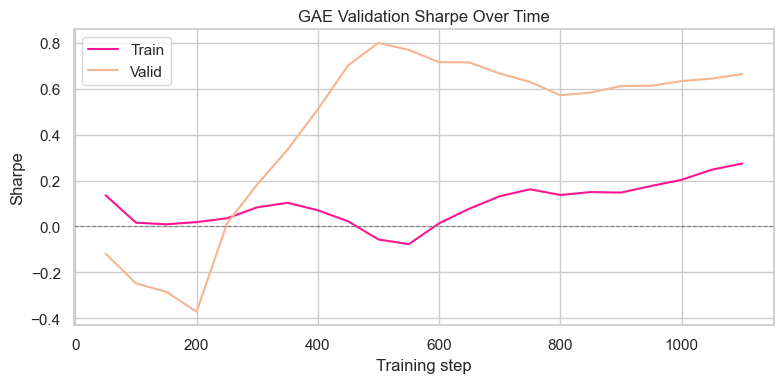

In [41]:
# Plot validation Sharpe trajectory
if history_ac and history_ac.get("eval_step"):
    hist_df = pd.DataFrame({
        "step": history_ac["eval_step"],
        "train_sharpe": history_ac.get("train_sharpe", []),
        "valid_sharpe": history_ac.get("valid_sharpe", []),
    })
    display(hist_df.tail())

    plt.figure(figsize=(8, 4))
    plt.plot(hist_df["step"], hist_df["train_sharpe"], label="Train", color='deeppink')
    plt.plot(hist_df["step"], hist_df["valid_sharpe"], label="Valid")
    plt.title("GAE Validation Sharpe Over Time")
    plt.xlabel("Training step")
    plt.ylabel("Sharpe")
    plt.axhline(0.0, color="grey", lw=0.8, ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation history recorded.")


In [42]:
# Simple ML comparator (Gradient Boosting) using same features/split
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Use the same train split as the RL agent
train_mask = panel["date"] <= pd.Timestamp(FINAL_PARAMS["train_end"])
X_raw = panel.loc[train_mask, state_cols]
y_raw = panel.loc[train_mask, "ret_fwd"]

# Drop any rows with NaNs in features or target so the
# GradientBoostingRegressor sees a clean matrix.
valid_rows = X_raw.notna().all(axis=1) & y_raw.notna()
X_train = X_raw.loc[valid_rows].to_numpy()
y_train = y_raw.loc[valid_rows].to_numpy() * 1e4  # work in bps

# Fit scaler on the filtered training data
mu_ml = X_train.mean(axis=0)
sg_ml = X_train.std(axis=0, ddof=1)
sg_ml[sg_ml == 0] = 1.0
X_train = (X_train - mu_ml) / sg_ml

# Slightly more robust GBT for noisy returns
gbr = GradientBoostingRegressor(
    random_state=42,
    n_estimators=400,
    max_depth=8,
    learning_rate=0.001,
    subsample=0.5,
)
gbr.fit(X_train, y_train)

# Calibrate a scale/sign so typical predictions map into [-pos_limit, pos_limit]
pred_train = gbr.predict(X_train)
abs_p = np.abs(pred_train)
scale_ml = np.percentile(abs_p, 90.0) if abs_p.size else 1.0
if not np.isfinite(scale_ml) or scale_ml <= 0:
    scale_ml = 1.0
corr_ml = np.corrcoef(pred_train, y_train)[0, 1] if pred_train.size else 0.0
sign_ml = -1.0 if np.isfinite(corr_ml) and corr_ml < 0 else 1.0
print(f"ML baseline: corr={corr_ml:.3f}, scale={scale_ml:.1f}, sign={sign_ml:+.1f}")

class MLPolicy:
    def __init__(self, model, mu, sg, pos_limit, scale, sign):
        self.model = model; self.mu = mu; self.sg = sg
        self.pos_limit = pos_limit; self.scale = scale; self.sign = sign
    def act(self, obs, deterministic=True):
        x = obs[-1] if obs.ndim > 1 else obs
        x_norm = (np.asarray(x, float) - self.mu) / self.sg
        pred = float(self.model.predict(x_norm.reshape(1, -1))[0])  # predicted bps
        raw = self.sign * pred / self.scale  # directional overlay, scaled & signed
        hedge = np.clip(raw * self.pos_limit, -self.pos_limit, self.pos_limit)
        return float(hedge), None, None

ml_policy = MLPolicy(
    gbr, mu_ml, sg_ml,
    pos_limit=float(FINAL_CFG["pos_limit"]),
    scale=scale_ml,
    sign=sign_ml,
)

# Persist ML baseline alongside the RL run for diagnostics
import pickle
ml_path = RUN_DIR / "ml_model.pkl"
with open(ml_path, "wb") as f:
    pickle.dump(
        {
            "model": gbr,
            "mu": mu_ml,
            "sg": sg_ml,
            "scale": scale_ml,
            "sign": sign_ml,
        },
        f,
    )
print(f"Saved ML baseline to {ml_path}")

ML baseline: corr=0.239, scale=4.8, sign=+1.0
Saved ML baseline to /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked/models/gae_4/ml_model.pkl


In [43]:
# Compare GAE policy against baselines (deterministic evaluation)
from collections import OrderedDict
from rl_agent.metrics import nav_from_bps, max_drawdown
from simulator.baselines import vix_band_policy, vix_vol_target, volatility_targeting

def _wrap_callable(fn):
    class _Tmp:
        def __init__(self, f):
            self.f = f
        def act(self, obs, deterministic=True):
            return float(self.f(obs)), None, None
    return _Tmp(fn)

# Baseline actors (match diagnostics notebook)
train_mask = panel["date"] <= pd.Timestamp(FINAL_CFG["train_end"])
vix_mean = float(panel.loc[train_mask, "vix"].mean()) if "vix" in panel else 0.0
vix_std = float(panel.loc[train_mask, "vix"].std(ddof=1)) if "vix" in panel else 1.0
feat_idx = {name: i for i, name in enumerate(FINAL_CFG["state_cols"])}
vix_idx = feat_idx.get("vix", 0)

long_spy_actor = _wrap_callable(lambda obs: FINAL_CFG["pos_limit"])
ml_actor = ml_policy
vix_band_actor = _wrap_callable(vix_band_policy(
    vix_idx=vix_idx,
    low=20.0,
    high=30.0,
    pos_low=0.0,
    pos_high=float(FINAL_CFG["pos_limit"]),
    vix_mean=vix_mean,
    vix_std=vix_std,
))
vix_vol_actor = _wrap_callable(vix_vol_target(
    vix_idx=vix_idx,
    vix_target=20.0,
    max_pos=float(FINAL_CFG["pos_limit"]),
    vix_mean=vix_mean,
    vix_std=vix_std,
))
vol_target_actor = _wrap_callable(volatility_targeting(feature_idx=vix_idx, ann_vol_target=0.15))

policies = OrderedDict({
    'gae_policy': policy_ac,
    'long_spy': long_spy_actor,
    'ml_gbr': ml_actor,
    'vix_band': vix_band_actor,
    'vix_vol_target': vix_vol_actor,
    'vol_target': vol_target_actor,
})

results = []
for name, pol in policies.items():
    for split, env in [('train', envs['env_tr']), ('valid', envs['env_va']), ('test', envs['env_te'])]:
        r = deterministic_rewards(env, pol)
        nav = nav_from_bps(r)
        mean = r.mean()
        std = r.std(ddof=1) if r.size > 1 else 0.0
        sharpe = (mean / std * np.sqrt(252)) if std > 0 else 0.0
        results.append({
            'policy': name, 'split': split, 'mean': mean, 'std': std, 'sharpe': sharpe,
            'max_dd': max_drawdown(nav), 'hit_rate': float((r > 0).mean()), 'steps': int(r.size),
        })
results_df = pd.DataFrame(results)
display(results_df)


,policy,split,mean,std,sharpe,max_dd,hit_rate,steps
0,gae_policy,train,-0.271578,75.429466,-0.057155,-0.661724,0.028539,7008
1,gae_policy,valid,2.615717,51.885223,0.800290,-0.084747,0.019447,1954
2,gae_policy,test,1.572734,53.054968,0.470576,-0.182652,0.018329,7529
3,long_spy,train,3.417795,114.803934,0.472595,-0.738260,0.032392,7008
4,long_spy,valid,2.123508,80.072330,0.420990,-0.260553,0.021494,1954
5,long_spy,test,1.189466,84.546524,0.223335,-0.525042,0.017134,7529
6,ml_gbr,train,1.693023,99.787010,0.269333,-0.476150,0.028253,7008
7,ml_gbr,valid,3.249782,69.719091,0.739951,-0.113140,0.014841,1954
8,ml_gbr,test,0.526057,79.321844,0.105279,-0.565410,0.014876,7529
9,vix_band,train,0.366849,43.230439,0.134709,-0.388928,0.009275,7008


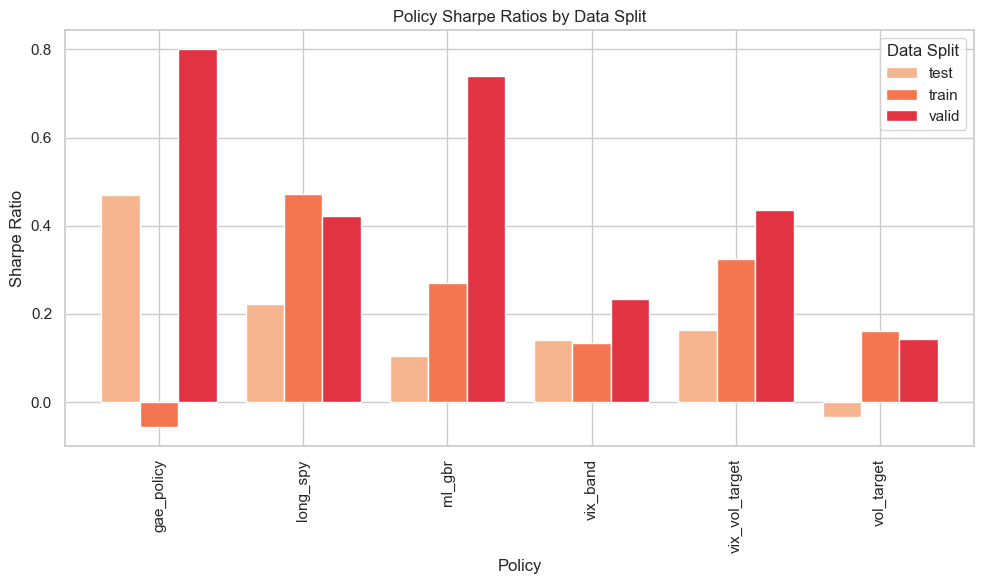

In [44]:
import seaborn as sns

pivot = results_df.pivot(index="policy", columns="split", values="sharpe")

#Plotting the pivot table
sns.set_theme(style="whitegrid")
sns.set_palette("rocket_r")
pivot.plot(kind='bar', figsize=(10,6), width=0.8)
plt.title('Policy Sharpe Ratios by Data Split')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Policy')
plt.legend(title='Data Split')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / "policy_sharpe_ratios.png", dpi=150)
plt.show()


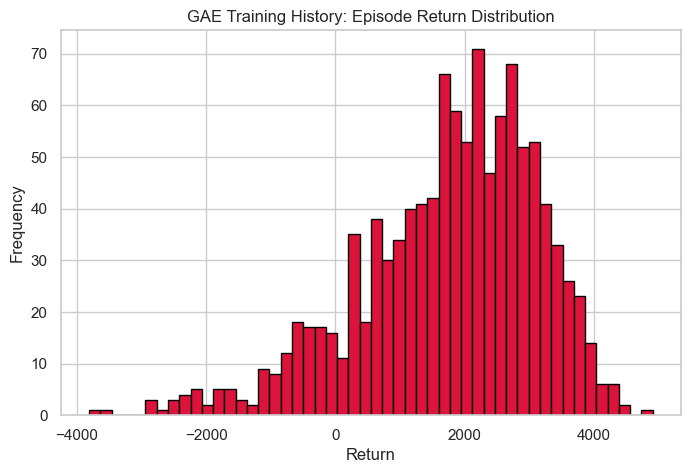

In [45]:
returns = pd.Series(history_ac['episode_return'])

returns.hist(bins=50, figsize=(8, 5), color='crimson', edgecolor='black')
plt.title("GAE Training History: Episode Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.savefig(ROOT / 'reports' / 'figures' / "gae_episode_return_distribution.png")
plt.show()

In [46]:
# Export best run to standard name for downstream notebooks
import shutil
RUN_DIR_EXPORT = ROOT / 'models' / 'gae_run4'
RUN_DIR_EXPORT.mkdir(parents=True, exist_ok=True)
shutil.copytree(RUN_DIR, RUN_DIR_EXPORT, dirs_exist_ok=True)
print(f'Exported best run from {RUN_DIR} -> {RUN_DIR_EXPORT}')


Exported best run from /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked/models/gae_4 -> /Users/roxanagreenleaf/Desktop/deep-hedging-rl-forked/models/gae_run4
